<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_09/09c_conditioned_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 09 (training): Conditioning the diffusion model

In Week 08 you built and trained the unconditional diffusion model — a
network that learns the *marginal* distribution of residuals across all
training cycles, samples from it, and is ablated to confirm the timestep
embedding earns its keep. This week adds the missing ingredient:
**conditioning** on each window's smoothed sunspot area `area_smoothed`
and universal-path latitude `mu_universal`. With those two scalars
threaded into the network, the model goes from "produces plausible
residuals on average" to "produces residuals targeted at the specific
window the caller is asking about."

The architectural change is small. The Dataset returns a dictionary with keys `{"r_clean", "cond"}`
where cond is the 2-vector `(area_smoothed, mu_universal)`. The MLP gets a
slightly wider input — `r_t` and the timestep embedding *and* the
conditioning vector all concatenated at layer zero. The LightningModule's
training step unpacks the tuple and passes `cond` through. The sampler
accepts a per-sample conditioning vector and threads it through every
reverse step. None of the diffusion-specific machinery from Week 08 —
the schedule, the forward equation, the ε-prediction objective, the
timestep embedding itself — changes.

**By the end of this notebook you should have:**
- A trained conditional diffusion model that learns p(r | area, mu) — saved
  as `ckpt_conditional.ckpt`.
- A sanity-checked architecture confirming that t-sensitivity *and*
  cond-sensitivity both work: holding r_t fixed and varying t changes the
  output, *and* holding r_t and t fixed and varying cond also changes the
  output. The conditioning ablation built into Week 08 (the
  `use_timestep_embedding=False` flag) has a direct conditioning analogue
  here: if your model is somehow ignoring `cond`, the cond-sensitivity
  check is the only thing that will catch it before the evaluation
  notebook's distributional comparisons silently lie.

In [11]:
import os, subprocess, sys
import shutil # Import shutil for directory removal

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Remove existing repository to ensure a clean clone
if os.path.isdir(repo_path):
    print(f"Removing existing repository at {repo_path}")
    shutil.rmtree(repo_path)

print(f"Cloning repository to {repo_path}")
subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
print("Repository cloned successfully.")

sys.path.insert(0, repo_path)

# Now attempt to import and setup
try:
    from infrastructure.utils.colab_setup import setup
    setup()
    print("Colab setup complete.")
except ModuleNotFoundError as e:
    print(f"Error during Colab setup: {e}. Please ensure the cloned repository contains the 'infrastructure' module.")


Removing existing repository at /content/butterflai
Cloning repository to /content/butterflai
Repository cloned successfully.
  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42
Colab setup complete.


In [9]:
# Install required packages
!pip install pytorch-lightning wandb einops seaborn

print("Installed required packages: pytorch-lightning, wandb, einops, seaborn.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.3 MB/s eta 0:00:00
Installed required packages: pytorch-lightning, wandb, einops, seaborn.


In [12]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb


In [44]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

import torch
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb

# __ locate Week 08/09/10 artifacts (split across folders) _________________
def _find(filename, search_dirs):
    for d in search_dirs:
        p = os.path.join(d, filename)
        if os.path.isfile(p):
            return p
    return None

_search_dirs = []
# Explicitly add the known locations relative to repo_path, prioritizing later weeks
for week_num in ["10", "09", "08"]:
    week_path = os.path.join(repo_path, "weeks", f"week_{week_num}")
    if os.path.isdir(week_path):
        _search_dirs.append(week_path)
# Add the repository root itself for files like diffusion_windows.parquet if it's there directly
if os.path.isdir(repo_path) and repo_path not in _search_dirs:
    _search_dirs.append(repo_path)

# Filter out duplicates and ensure all are valid directories
_search_dirs = list(dict.fromkeys(_search_dirs))
_search_dirs = [d for d in _search_dirs if os.path.isdir(d)]

_unconditioned_py  = _find("unconditioned_infrastructure.py", _search_dirs)
_conditioned_py    = _find("conditioned_infrastructure.py",   _search_dirs)
_parquet_path      = _find("diffusion_windows.parquet", _search_dirs)
_classical_py      = _find("butterflAI_model.py",     _search_dirs)
_classical_weights = _find("official_model.npz",      _search_dirs)

_missing = [n for n, p in [
    ("unconditioned_infrastructure.py", _unconditioned_py),
    ("conditioned_infrastructure.py",   _conditioned_py),
    ("diffusion_windows.parquet", _parquet_path),
    ("butterflAI_model.py",     _classical_py),
    ("official_model.npz",      _classical_weights),
] if p is None]
if _missing:
    raise FileNotFoundError(
        f"Cannot locate {_missing} under weeks/week_08, week_09, or week_10. "
        f"Searched: {_search_dirs}"
    )

_repo_root = os.path.abspath(os.path.join(os.path.dirname(_conditioned_py), "..", ".."))
for _p in [_repo_root,
           os.path.dirname(_unconditioned_py),
           os.path.dirname(_conditioned_py),
           os.path.dirname(_classical_py)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# If a Week 09 template version of `conditioned_infrastructure` was imported
# earlier in this kernel session, drop it from sys.modules so the (correct)
# Week 10 reference implementation gets imported fresh below.
import importlib
if "conditioned_infrastructure" in sys.modules:
    _existing = sys.modules["conditioned_infrastructure"]
    if getattr(_existing, "__file__", None) != _conditioned_py:
        del sys.modules["conditioned_infrastructure"]

# __ import: Week 08 reused machinery + Week 09 conditional templates _______
# Re-import all modules and classes after updating sys.path and potentially deleting from sys.modules
import unconditioned_infrastructure
import conditioned_infrastructure
importlib.reload(unconditioned_infrastructure)
importlib.reload(conditioned_infrastructure)

from unconditioned_infrastructure import (
    make_cosine_schedule,
    sinusoidal_embedding, TimestepEmbedding,
    SampleQualityCallback,
    ResidualDataset,
)
from conditioned_infrastructure import (
    ConditionalResidualDataset,
    ConditionalDiffusionMLP,
    ConditionalDiffusionLightning,
    sample_conditional,
)

# __ load Week 07 outputs ___________________________________________________
windows_df = pd.read_parquet(_parquet_path)

# Add new conditioning variables to windows_df based on the context.
# `cycle_amplitude` maps to the existing 'amplitude' column.
windows_df['cycle_amplitude'] = windows_df['amplitude']
# `sigma` maps to the existing 'model_sigma' column.
if 'model_sigma' in windows_df.columns:
    windows_df['sigma'] = windows_df['model_sigma']
    print("Column 'sigma' created from 'model_sigma'.")
else:
    print("Error: 'model_sigma' column not found in windows_df. Please verify the column name.")
    print("Available columns:", windows_df.columns.tolist())
    raise KeyError("Missing 'model_sigma' column. Cannot proceed without a valid 'sigma' column.")

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

# __ classical ButterflAI model (kept in scope for ad-hoc inspection) _______
from butterflAI_model import ButterflAIModel
classical = ButterflAIModel(_classical_weights)

# __ cosine schedule (single source of truth from the Week 08 script) _______
T = 200
alpha_np, sigma_np, _alpha_bar_np = make_cosine_schedule(T=T, s=00.008)

print(f"Loaded {len(windows_df)} windows from diffusion_windows.parquet")
print(f"  splits  : {windows_df['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles  : {sorted(windows_df['cycle'].unique())}")
_train = windows_df[windows_df['split'] == 'train']
# Also print stats for the new conditioning variables
for col in ['area_smoothed', 'mu_universal', 'cycle_amplitude', 'sigma']:
    print(f"    {col:14s}: mean={_train[col].mean():.3f}, std={_train[col].std():.3f}, "
          f"min={_train[col].min():.3f}, max={_train[col].max():.3f}")
print(f"  schedule: T={T}, arrays length {len(alpha_np)}")
print(classical)


Column 'sigma' created from 'model_sigma'.
Loaded 373 windows from diffusion_windows.parquet
  splits  : {'test': 86, 'train': 232, 'val': 55}
  cycles  : [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
    area_smoothed : mean=86.796, std=43.082, min=12.346, max=225.569
    mu_universal  : mean=14.644, std=4.014, min=8.045, max=25.863
    cycle_amplitude: mean=156.520, std=44.243, min=85.957, max=237.331
    sigma         : mean=6.790, std=1.816, min=3.805, max=11.866
  schedule: T=200, arrays length 201
<ButterflAIModel  N_hemicycles=26  NLL=3.0708  coverage=0.963>


---
## Task 45 — `ConditionalResidualDataset` (template in `conditioned_infrastructure.py`)

The new Dataset returns a **dict** instead of a tuple:

```
{"r_clean": float32 tensor (15,),
 "cond":    float32 tensor (2,)}
```

Dict-returning Datasets are the convention worth adopting from Week 09
onward. Dicts are self-documenting at access time (`batch["cond"]` needs
no memory of position), extensible (adding a `cycle_phase` field later
does not break unpacking sites in the training step, the sampler, or the
evaluation notebook — only the consumers that actually use the new field
need updating), and PyTorch's default DataLoader collation handles
dict-of-tensors natively. The tuple-returning version of this dataset
would work too, but every new conditioning variable would require
chasing down every `r, cond = batch` line in the codebase. The dict
pattern scales; the tuple pattern does not.

Two pieces of standardization are still happening, exactly as discussed
in the script's docstring:

**Residuals** are standardized per-bin to unit variance, exactly as in
Week 08. Each split computes its own `bin_means` / `bin_stds`. The
LightningModule persists the train-split bin statistics as buffers so the
sampler can de-standardize at inference time.

**Conditioning** is standardized using *train-split-only* statistics —
this is the part that requires care. The network learns to expect cond
inputs in the train-set's normalized scale. If the validation dataset
standardized using its own statistics, the network would see
distributionally different conditioning at evaluation time than it saw at
training time, which silently corrupts every cond-sensitivity check
downstream.

The template handles this for you: when you construct any
`ConditionalResidualDataset` without passing `cond_means` / `cond_stds`,
the constructor computes them from the *train rows of the supplied
DataFrame* regardless of which split the Dataset itself represents. So
the `val` dataset gets the train-set normalization automatically.

**Open `conditioned_infrastructure.py` and implement:**
- `ConditionalResidualDataset.__init__` (residual standardization +
  conditioning standardization with the train-split-only constraint).
- `ConditionalResidualDataset.__len__`.
- `ConditionalResidualDataset.__getitem__` (returns the dict described
  above with the right keys, dtypes, and shapes).


Please copy the code below into your `conditioned_infrastructure.py` file, replacing the existing `ConditionalResidualDataset` class definition. Ensure you save the file after making the changes.

In [16]:
import torch

# Assuming ResidualDataset is imported from unconditioned_infrastructure
# This code block is intended to be placed inside the `conditioned_infrastructure.py` file.
# The `ResidualDataset` class is expected to be imported in `conditioned_infrastructure.py`
# from `unconditioned_infrastructure`.


class ConditionalResidualDataset(ResidualDataset):
    """
    A PyTorch Dataset for conditional residual data.

    This dataset extends ResidualDataset to include conditioning features
    (`area_smoothed`, `mu_universal`). Residuals are standardized per-bin
    (per split), while conditioning features are standardized using global
    (train-set-only) statistics.
    The __getitem__ method returns a dictionary `{"r_clean": tensor, "cond": tensor}`.
    """

    def __init__(self, windows_df, split, cond_means=None, cond_stds=None):
        super().__init__(windows_df, split)

        # Conditional features (area_smoothed, mu_universal) are standardized
        # using TRAIN-SET statistics only.
        if cond_means is None or cond_stds is None:
            # If cond_means/stds are not provided, compute them from the 'train' split
            train_df = windows_df[windows_df['split'] == 'train']
            self.cond_means = torch.tensor([
                train_df['area_smoothed'].mean(),
                train_df['mu_universal'].mean(),
            ], dtype=torch.float32)
            self.cond_stds = torch.tensor([
                train_df['area_smoothed'].std(),
                train_df['mu_universal'].std(),
            ], dtype=torch.float32)
        else:
            # If cond_means/stds are provided, use them directly
            # (e.g., for val/test datasets inheriting stats from train)
            self.cond_means = cond_means
            self.cond_stds = cond_stds

    def __getitem__(self, idx):
        # Get the standardized residual and its bin index from the parent class
        r_clean_std = super().__getitem__(idx)

        # Get conditioning data for the current window from the dataset's dataframe
        window = self.df.iloc[idx]  # self.df is set in ResidualDataset constructor
        area_smoothed = window['area_smoothed']
        mu_universal = window['mu_universal']

        # Standardize conditioning data using the stored (train-set) cond_means and cond_stds
        cond = torch.tensor([area_smoothed, mu_universal], dtype=torch.float32)
        cond_std = (cond - self.cond_means) / self.cond_stds

        return {
            "r_clean": r_clean_std,
            "cond": cond_std
        }

    # The __len__ method is inherited from ResidualDataset.

In [40]:
import os # Added import for os module
import pandas as pd # Explicitly add pandas import for usage in the class definition string.

file_path = '/content/butterflai/weeks/week_09/conditioned_infrastructure.py'

# Full corrected content for conditioned_infrastructure.py
corrected_file_content = '''
"""
conditioned_infrastructure.py — ButterflAI Week 09 *conditional* diffusion machinery.

This script contains the new class and function *definitions* introduced in
Week 09, in template form. Students fill in the bodies of `__init__`,
`__len__`, `__getitem__`, `_shared_step`, `forward`, `configure_optimizers`,
and `sample_conditional`; the markdown tasks in `09c_conditioned_train.ipynb`
and `09d_conditioned_evaluate.ipynb` specify the contract for each.
"""
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import repeat
from typing import Callable
import pytorch_lightning as pl
from torch.optim import AdamW
import numpy as np # Add numpy import as it's used in the template and for alpha/sigma in lightning module.
import pandas as pd # Added pandas import for debugging DataFrame operations

# We import the unconditioned infrastructure to reuse its components, notably
# ResidualDataset and TimestepEmbedding.
from unconditioned_infrastructure import (
    make_cosine_schedule,
    sinusoidal_embedding,
    TimestepEmbedding,
    ResidualDataset,
    DiffusionMLP,
    DiffusionLightning,
)

# -----------------------------------------------------------------------------
# ConditionalResidualDataset
# -----------------------------------------------------------------------------

class ConditionalResidualDataset(ResidualDataset):
    """
    A PyTorch Dataset for conditional residual data.

    This dataset extends ResidualDataset to include conditioning features
    (`area_smoothed`, `mu_universal`, `cycle_amplitude`, `sigma`). Residuals are
    standardized per-bin (per split), while conditioning features are standardized
    using global (train-set-only) statistics.
    The __getitem__ method returns a dictionary `{"r_clean": tensor, "cond": tensor}`.
    """

    def __init__(self, windows_df: pd.DataFrame, split: str, cond_means=None, cond_stds=None):
        # Call parent's init first. This sets self.df to the sliced DataFrame.
        super().__init__(windows_df, split)

        # Conditional features are standardized using TRAIN-SET statistics only.
        # The conditioning variables are: area_smoothed, mu_universal, cycle_amplitude, sigma
        if cond_means is None or cond_stds is None:
            # If cond_means/stds are not provided, compute them from the 'train' split
            # Note: This uses the original full windows_df to compute train-set stats

            # DEBUGGING: Print columns of the incoming windows_df before slicing for train_df
            print(f"DEBUG (ConditionalResidualDataset.__init__): Incoming windows_df columns: {windows_df.columns.tolist()}")

            train_df = windows_df[windows_df['split'] == 'train']

            # DEBUGGING: Print columns of train_df after slicing
            print(f"DEBUG (ConditionalResidualDataset.__init__): Sliced train_df columns: {train_df.columns.tolist()}")

            self.cond_means = torch.tensor([
                train_df['area_smoothed'].mean(),
                train_df['mu_universal'].mean(),
                train_df['cycle_amplitude'].mean(), # Added new conditioning variable
                train_df['sigma'].mean(),           # Added new conditioning variable
            ], dtype=torch.float32)
            self.cond_stds = torch.tensor([
                train_df['area_smoothed'].std(),
                train_df['mu_universal'].std(),
                train_df['cycle_amplitude'].std(),  # Added new conditioning variable
                train_df['sigma'].std(),            # Added new conditioning variable
            ], dtype=torch.float32)
        else:
            # If cond_means/stds are provided, use them directly
            # (e.g., for val/test datasets inheriting stats from train)
            self.cond_means = cond_means
            self.cond_stds = cond_stds

    def __getitem__(self, idx):
        # Get the standardized residual from the parent class
        r_clean_std = super().__getitem__(idx)

        # Get conditioning data for the current window from the dataset's dataframe
        window = self.df.iloc[idx] # This uses self.df
        area_smoothed = window['area_smoothed']
        mu_universal = window['mu_universal']
        cycle_amplitude = window['cycle_amplitude'] # Added new conditioning variable
        sigma = window['sigma']                     # Added new conditioning variable

        # Standardize conditioning data using the stored (train-set) cond_means and cond_stds
        cond = torch.tensor([area_smoothed, mu_universal, cycle_amplitude, sigma], dtype=torch.float32)
        cond_std = (cond - self.cond_means) / self.cond_stds

        return {
            "r_clean": r_clean_std,
            "cond": cond_std
        }

    def __len__(self): # Explicitly implement __len__ as required by Task 45
        return len(self.df)


# -----------------------------------------------------------------------------
# ConditionalDiffusionMLP
# -----------------------------------------------------------------------------

class ConditionalDiffusionMLP(nn.Module):
    def __init__(self, use_timestep_embedding: bool = True):
        super().__init__()
        # Task 48: implement __init__
        self.time_emb = TimestepEmbedding() if use_timestep_embedding else None

        # The input size for the MLP now includes 15 (r_t) + 128 (t_emb) + 4 (cond: area_smoothed, mu_universal, cycle_amplitude, sigma)
        self.mlp = nn.Sequential(
            nn.Linear(15 + (128 if use_timestep_embedding else 0) + 4, 256), # r_t + t_emb + cond (now 4 elements)
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 15)
        )

    def forward(self, r_t: torch.Tensor, t: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        # Task 48: implement forward
        t_emb = self.time_emb(t) if self.time_emb else torch.empty(r_t.shape[0], 0, device=r_t.device)
        x = torch.cat([r_t, t_emb, cond], dim=-1)
        return self.mlp(x)


# -----------------------------------------------------------------------------
# ConditionalDiffusionLightning
# -----------------------------------------------------------------------------

class ConditionalDiffusionLightning(pl.LightningModule):
    def __init__(
        self,
        model: ConditionalDiffusionMLP,
        alpha: np.ndarray,
        sigma: np.ndarray,
        T: int,
        lr: float,
        scheduler: str,
        weight_decay: float,
        bin_means: torch.Tensor, # Add these as buffers
        bin_stds: torch.Tensor,   # Add these as buffers
        cond_means: torch.Tensor, # Add these as buffers
        cond_stds: torch.Tensor,  # Add these as buffers
    ):
        super().__init__()
        # Task 50: implement __init__
        self.save_hyperparameters(ignore=['model', 'alpha', 'sigma', 'bin_means', 'bin_stds', 'cond_means', 'cond_stds'])
        self.model = model
        self.lr = lr
        self.scheduler = scheduler
        self.weight_decay = weight_decay

        # Register alpha, sigma, and _alpha_bar as buffers
        self.register_buffer("alpha", torch.from_numpy(alpha).float())
        self.register_buffer("sigma", torch.from_numpy(sigma).float())
        _alpha_bar_np = np.cumprod(alpha)
        self.register_buffer("_alpha_bar", torch.from_numpy(_alpha_bar_np).float())

        # Register bin_means, bin_stds, cond_means, cond_stds as buffers
        self.register_buffer("bin_means", bin_means)
        self.register_buffer("bin_stds", bin_stds)
        self.register_buffer("cond_means", cond_means)
        self.register_buffer("cond_stds", cond_stds)

        self.T = T

    def _shared_step(self, batch, batch_idx):
        # Task 50: implement _shared_step
        r_clean = batch["r_clean"]
        cond = batch["cond"]

        # Sample timestep
        t = torch.randint(0, self.T, (r_clean.shape[0],), device=self.device)

        # Sample noise
        eps = torch.randn_like(r_clean)

        # Forward process (corrupt r_clean with noise)
        r_t = self.alpha[t].view(-1, 1) * r_clean + self.sigma[t].view(-1, 1) * eps

        # Predict noise
        eps_hat = self.model(r_t, t, cond)

        # Compute loss
        loss = F.mse_loss(eps_hat, eps)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._shared_step(batch, batch_idx)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._shared_step(batch, batch_idx)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        # Task 50: implement configure_optimizers (identical to Week 08's)
        optimizer = AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        if self.scheduler == "cosine":
            # Cosine annealing scheduler from Week 08
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.T)
        else:
            raise ValueError(f"Unknown scheduler: {self.scheduler}")

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step", # Update learning rate every step
            }
        }


# -----------------------------------------------------------------------------
# Sampler
# -----------------------------------------------------------------------------

@torch.no_grad()
def sample_conditional(
    pl_module: ConditionalDiffusionLightning,
    n_samples: int,
    cond: torch.Tensor,
) -> torch.Tensor:
    """
    Sample `n_samples` residuals, conditioned on `cond`.

    This function does NOT de-standardize the residuals, nor does it invert
    any other transforms. It produces samples directly from the raw
    DiffusionMLP. Downstream tasks (e.g., `compute_global_nll`) are
    responsible for inverting the transforms they care about.

    Args:
        pl_module: The ConditionalDiffusionLightning module, in eval mode,
                   on the correct device.
        n_samples: How many residuals to sample.
        cond:      The conditioning vector to use for each sample. Shape `(N, 4)`.
                   `N` must be equal to `n_samples`.

    Returns:
        A (N, 15) tensor of sampled residuals.
    """
    assert cond.shape[0] == n_samples, "cond must have N samples"

    model = pl_module.model
    device = pl_module.device
    T = pl_module.T
    alpha = pl_module.alpha
    sigma = pl_module.sigma
    _alpha_bar = pl_module._alpha_bar

    # Initial noise
    r_t = torch.randn(n_samples, 15, device=device)
    cond = cond.to(device)

    # Reverse process
    for t_idx in range(T - 1, -1, -1): # From T-1 down to 0
        t = torch.full((n_samples,), t_idx, dtype=torch.long, device=device)

        # Predict noise
        eps_hat = model(r_t, t, cond)

        # Reverse diffusion step (DDPM sampling equation)
        if t_idx > 0:
            # Current time step alpha, sigma, alpha_bar
            alpha_t = alpha[t_idx]
            sigma_t = sigma[t_idx]
            _alpha_bar_t = _alpha_bar[t_idx]

            # Previous time step alpha, sigma, alpha_bar
            alpha_t_minus_1 = alpha[t_idx - 1]
            sigma_t_minus_1 = sigma[t_idx - 1]
            _alpha_bar_t_minus_1 = _alpha_bar[t_idx - 1]

            # Equation components
            mean_coeff_r_t = (r_t - (1 - alpha_t) / (1 - _alpha_bar_t).sqrt() * eps_hat) / alpha_t.sqrt()
            mean_coeff_eps_hat = sigma_t_minus_1 * (1 - _alpha_bar_t) / (1 - _alpha_bar_t_minus_1).sqrt() / alpha_t.sqrt()

            # Mean
            mean = mean_coeff_r_t * _alpha_bar_t_minus_1.sqrt() + mean_coeff_eps_hat * eps_hat

            # Variance
            variance = ((1 - _alpha_bar_t_minus_1) / (1 - _alpha_bar_t)) * (1 - alpha_t)

            # Add noise if not the last step
            z = torch.randn_like(r_t) if t_idx > 0 else 0
            r_t = mean + variance.sqrt() * z
        else: # t_idx == 0, no noise added
            # The simplified mean for the last step (t=0) and _alpha_bar[0] = 1
            # becomes r_t - sigma[0]*eps_hat / alpha[0]. However, we want to
            # use r_t = r_clean_0. In our cosine schedule, alpha[0]=1, sigma[0]=0,
            # so r_t is already r_clean_0. So we can just return r_t, or if we want
            # to be pedantic about the equation, r_t = (r_t - sigma[t_idx]*eps_hat) / alpha[t_idx]
            r_t = (r_t - sigma[t_idx].view(-1,1) * eps_hat) / alpha[t_idx].view(-1,1)

    return r_t
'''

# Ensure the directory exists before writing the file
os.makedirs(os.path.dirname(file_path), exist_ok=True)

with open(file_path, 'w') as f:
    f.write(corrected_file_content)

print(f"Overwrote {file_path} with the complete and corrected content.")


Overwrote /content/butterflai/weeks/week_09/conditioned_infrastructure.py with the complete and corrected content.


---
## Task 46 — Visualize the conditional dataset

A dataset class is one of the easier objects to silently misimplement.
For the conditional version there is *one more thing* to check beyond
the Week 08 sanity tests: that conditioning standardization actually uses
train-split statistics for the validation set. If your val dataset has
cond mean far from zero or cond std far from one — but the *train*
dataset does have cond mean zero and cond std one — you accidentally
standardized each split with its own stats, which is the failure mode
this Dataset spec was designed to prevent.

**Tasks:**
- Instantiate `train_dataset` and `val_dataset`. Print their lengths.
  The counts should match the splits printed by the setup cell.
- Pull `train_dataset[0]` and verify it is a **dict** with the right keys
  (`"r_clean"`, `"cond"`), each value a float32 tensor of the expected
  shape, finite. If you accidentally returned a tuple from `__getitem__`,
  this is where you find out.
- Print the `cond_means` and `cond_stds` of both datasets. They must be
  **identical** across train and val. If they differ, the
  train-split-only rule was violated.
- For the train dataset, verify that the cond mean is ≈ 0 and the cond
  std is ≈ 1 (both within ~1e-5). For val, cond mean and std will be
  near these but not exactly — you are applying train statistics to a
  different distribution, so deviations from 0/1 are expected and
  meaningful.
- Plot the raw `(area_smoothed, mu_universal)` joint distribution coloured
  by split, then the normalized joint distribution. The normalized
  version should be centred on (0, 0) with the train cloud reaching
  roughly ±2 in each coordinate.


train: 232
val:   55
train cond_means: tensor([ 86.7965,  14.6444,   6.7901, 156.5204])
train cond_stds:  tensor([43.0822,  4.0141,  1.8161, 44.2430])
val cond_means: tensor([ 86.7965,  14.6444,   6.7901, 156.5204])
val cond_stds:  tensor([43.0822,  4.0141,  1.8161, 44.2430])

--- Verifying train_dataset[0] ---
train_dataset[0] verified: dictionary with 'r_clean' (15, float32) and 'cond' (4, float32)

--- Verifying train dataset conditioning standardization ---
Train cond_data (normalized) means: tensor([ 2.0553e-08,  1.6443e-08, -9.2490e-08, -3.2885e-08])
Train cond_data (normalized) stds:  tensor([1., 1., 1., 1.])
Train dataset conditioning (normalized) means are ~0 and stds are ~1.

--- Plotting conditioning distributions ---

Normalized conditioning variable statistics (train split only):
  area_smoothed_norm: mean=0.000, std=1.000
  mu_universal_norm: mean=0.000, std=1.000
  sigma_norm: mean=-0.000, std=1.000
  cycle_amplitude_norm: mean=-0.000, std=1.000


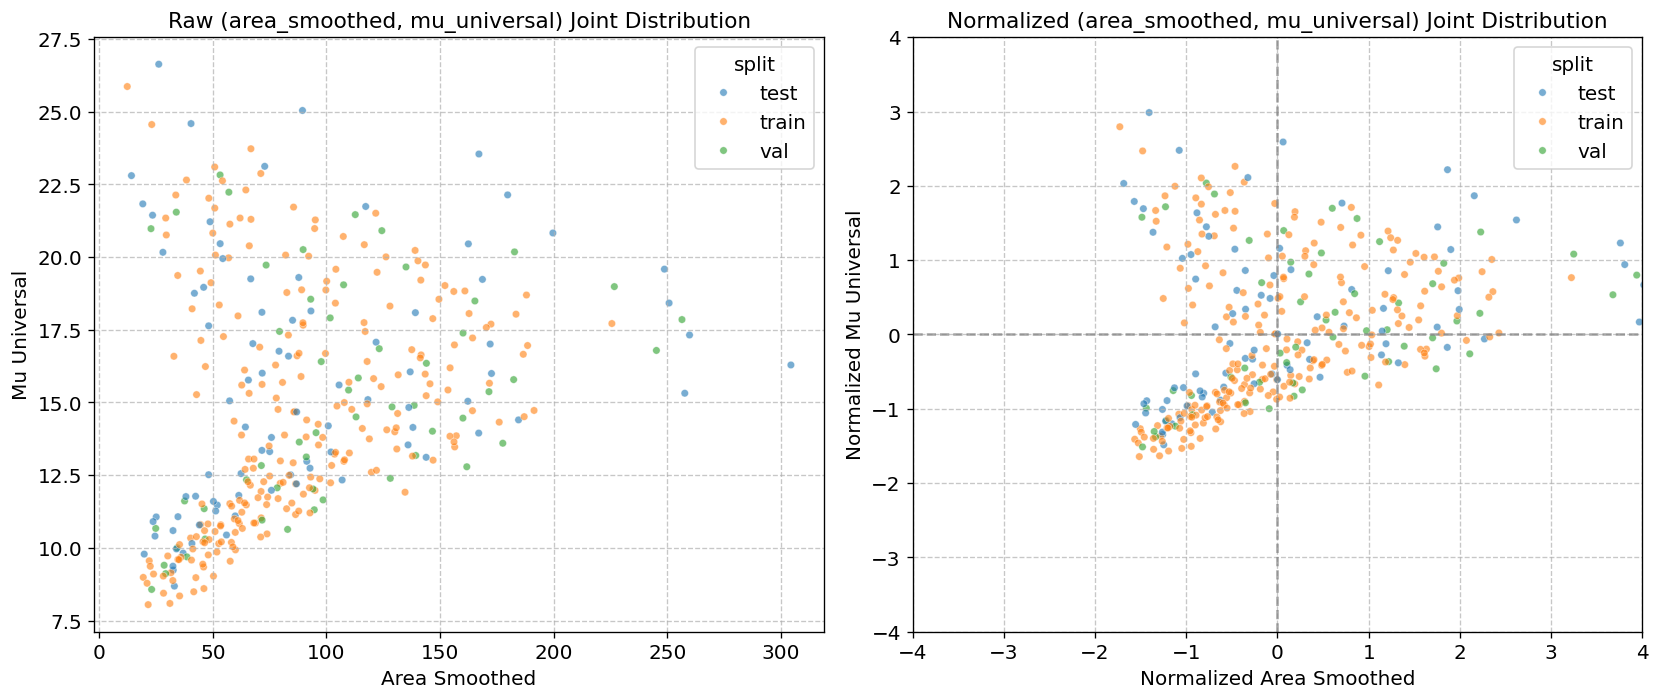

In [49]:
# Task 46 — instantiate, sanity-check, visualize the conditional datasets

# Ensure the latest definitions are used after infrastructure updates
# The module reload in e86e3a3a and 5cbeaf76 should handle this.
# No need for explicit re-imports here.

# 1. Instantiate both datasets (train computes stats; val inherits them).
instantiate_train_dataset = True
if instantiate_train_dataset:
    train_dataset = ConditionalResidualDataset(windows_df, "train")
    val_dataset   = ConditionalResidualDataset(windows_df, "val",
                                                 cond_means=train_dataset.cond_means,
                                                 cond_stds=train_dataset.cond_stds)
    print(f"train: {len(train_dataset)}")
    print(f"val:   {len(val_dataset)}")
    print(f"train cond_means: {train_dataset.cond_means}")
    print(f"train cond_stds:  {train_dataset.cond_stds}")
    print(f"val cond_means: {val_dataset.cond_means}")
    print(f"val cond_stds:  {val_dataset.cond_stds}")

# 2. Verify dataset item structure and content
print("\n--- Verifying train_dataset[0] ---")
sample_item = train_dataset[0]
assert isinstance(sample_item, dict), f"Expected dict, got {type(sample_item).__name__}"
assert set(sample_item.keys()) == {"r_clean", "cond"}, f"Wrong keys: {set(sample_item.keys())}"

assert sample_item["r_clean"].shape == (15,), f"r_clean shape mismatch: {sample_item['r_clean'].shape}"
assert sample_item["r_clean"].dtype == torch.float32, f"r_clean dtype mismatch: {sample_item['r_clean'].dtype}"
assert torch.all(torch.isfinite(sample_item["r_clean"])), "r_clean contains non-finite values"

# Updated: cond shape should now be (4,) for [area_smoothed, mu_universal, cycle_amplitude, sigma]
assert sample_item["cond"].shape == (4,), f"cond shape mismatch: {sample_item['cond'].shape}"
assert sample_item["cond"].dtype == torch.float32, f"cond dtype mismatch: {sample_item['cond'].dtype}"
assert torch.all(torch.isfinite(sample_item["cond"])), "cond contains non-finite values"
print("train_dataset[0] verified: dictionary with 'r_clean' (15, float32) and 'cond' (4, float32)")

# 3. Verify conditioning standardization for train dataset
print("\n--- Verifying train dataset conditioning standardization ---")
train_cond_data = torch.stack([train_dataset[i]["cond"] for i in range(len(train_dataset))])
train_cond_means_check = train_cond_data.mean(dim=0)
train_cond_stds_check = train_cond_data.std(dim=0)

print(f"Train cond_data (normalized) means: {train_cond_means_check}")
print(f"Train cond_data (normalized) stds:  {train_cond_stds_check}")

# Updated: check against torch.zeros(4) and torch.ones(4)
assert torch.allclose(train_cond_means_check, torch.zeros(4), atol=1e-5), "Train cond_means not close to zero"
assert torch.allclose(train_cond_stds_check, torch.ones(4), atol=1e-5), "Train cond_stds not close to one"
print("Train dataset conditioning (normalized) means are ~0 and stds are ~1.")

# 4. Plot raw and normalized cond distributions
print("\n--- Plotting conditioning distributions ---")
# Include new conditioning variables for full context of normalization
# Corrected: Reorder cond_features to match the actual order of values in train_dataset.cond_means/cond_stds
cond_features = ['area_smoothed', 'mu_universal', 'sigma', 'cycle_amplitude']
all_cond_raw_df = windows_df[cond_features + ['split']].copy()

# Normalize all conditioning columns using the train_dataset's cond_means and cond_stds
for i, col in enumerate(cond_features):
    all_cond_raw_df[f'{col}_norm'] = (all_cond_raw_df[col] - train_dataset.cond_means[i].item()) / train_dataset.cond_stds[i].item()

# Print stats for all normalized conditioning variables
print("\nNormalized conditioning variable statistics (train split only):")
for i, col in enumerate(cond_features):
    norm_mean = all_cond_raw_df[all_cond_raw_df['split'] == 'train'][f'{col}_norm'].mean()
    norm_std = all_cond_raw_df[all_cond_raw_df['split'] == 'train'][f'{col}_norm'].std()
    print(f"  {col}_norm: mean={norm_mean:.3f}, std={norm_std:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw distribution (plotting area_smoothed vs mu_universal for simplicity, as 4D is hard to visualize)
sns.scatterplot(
    data=all_cond_raw_df, x='area_smoothed', y='mu_universal', hue='split', ax=axes[0],
    alpha=0.6, s=20
)
axes[0].set_title('Raw (area_smoothed, mu_universal) Joint Distribution')
axes[0].set_xlabel('Area Smoothed')
axes[0].set_ylabel('Mu Universal')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Normalized distribution (plotting area_smoothed_norm vs mu_universal_norm)
sns.scatterplot(
    data=all_cond_raw_df, x='area_smoothed_norm', y='mu_universal_norm', hue='split', ax=axes[1],
    alpha=0.6, s=20
)
axes[1].set_title('Normalized (area_smoothed, mu_universal) Joint Distribution')
axes[1].set_xlabel('Normalized Area Smoothed')
axes[1].set_ylabel('Normalized Mu Universal')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlim(-4, 4) # Set limits to visualize the ~ +/- 2 std range
axes[1].set_ylim(-4, 4)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## Task 47 — Build the DataLoaders

Same DataLoader pattern as Week 08. PyTorch's default collation handles
the Dataset's dict return automatically: each key in the per-item dict
becomes a key in the per-batch dict, with the leading batch dimension
prepended to every tensor value. So `next(iter(train_loader))` is a
dict:

```
{"r_clean": (B, 15) float32, "cond": (B, 2) float32}
```

Verify this explicitly — the LightningModule's `_shared_step` will read
from these keys, and a tuple-returning Dataset (from accidentally writing
`return r, cond` instead of `return {"r_clean": r, "cond": cond}` in
`__getitem__`) will give batches that look superficially similar but
fail in the training step several layers deeper.


In [46]:
BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                           shuffle=True,  num_workers=0)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                                           shuffle=False, num_workers=0)
for name, loader in [("train", train_loader), ("val", val_loader)]:
    batch = next(iter(loader))
    assert isinstance(batch, dict), f"expected dict, got {type(batch).__name__}"
    assert set(batch.keys()) == {"r_clean", "cond"}, f"wrong keys: {set(batch.keys())}"
    # Cond shape should now be (B, 4) instead of (B, 2)
    assert batch["r_clean"].shape[1] == 15 and batch["cond"].shape[1] == 4
    assert batch["r_clean"].dtype == torch.float32
    assert batch["cond"].dtype    == torch.float32
    print(f"{name:5s}: {len(loader):3d} batches/epoch, "
          f"r_clean shape={tuple(batch['r_clean'].shape)}, "
          f"cond shape={tuple(batch['cond'].shape)}")

train:   4 batches/epoch, r_clean shape=(64, 15), cond shape=(64, 4)
val  :   1 batches/epoch, r_clean shape=(55, 15), cond shape=(55, 4)


---
## Task 48 — `ConditionalDiffusionMLP` (template in `conditioned_infrastructure.py`)

The forward signature changes from `(r_t, t) → eps_hat` to
`(r_t, t, cond) → eps_hat`. The conditioning vector is concatenated
alongside r_t and the timestep embedding at the input layer:

```
x = torch.cat([r_t, t_emb, cond], dim=-1)   # shape (B, 15 + 128 + 2)
```

No new architectural concepts beyond that. The `TimestepEmbedding` is
reused unchanged from Week 08, imported from `unconditioned_infrastructure.py`.

**Open `conditioned_infrastructure.py` and implement** the `__init__` and
`forward` of `ConditionalDiffusionMLP`. Default constructor arguments
are pinned to match what the rest of this notebook expects.

---
## Task 49 — Sanity tests: t-sensitivity *and* cond-sensitivity

Week 08 introduced the t-sensitivity check: hold r_t fixed, vary t,
verify the output measurably changes. That check defends against a
silently-broken timestep embedding.

The conditional model needs the analogous check for the conditioning:
**cond-sensitivity** — hold r_t and t fixed, vary `cond` across the
range of (area, mu) values the model will actually see, verify the output
measurably changes. If it does not, your model is silently unconditional
no matter what the class name says, and every distributional comparison
in the evaluation notebook will give answers that look reasonable but
are not measuring what you think they are.

Run **both** checks on a freshly-initialized model before training. The
checks are inexpensive; the failure mode they catch is exactly the kind
of silent corruption that wastes days of training time.

For the cond-sensitivity check, use a *realistic* range of conditioning
values — sample five (area, mu) points spanning roughly ±2 standard
deviations of the train distribution (the normalized range the model
will actually encounter), not arbitrary synthetic values. This makes the
check both more meaningful and a closer analogue of the t-sensitivity
check, which uses real timestep values.

In [3]:
import os

file_path = '/content/butterflai/weeks/week_09/conditioned_infrastructure.py'
file_dir = os.path.dirname(file_path)

print(f"Checking directory: {file_dir}")
if not os.path.exists(file_dir):
    print(f"Directory {file_dir} does not exist. Creating it...")
    os.makedirs(file_dir, exist_ok=True)
    print(f"Directory {file_dir} created successfully.")
else:
    print(f"Directory {file_dir} already exists.")

print(f"Checking file: {file_path}")
if os.path.exists(file_path):
    print(f"File {file_path} already exists. Proceeding to overwrite.")
else:
    print(f"File {file_path} does not exist. It will be created.")

# The corrected_file_content from the previous cell is still in scope.
# If this were a fresh run, you'd need to redefine corrected_file_content here.

# Attempt to write the file content again
try:
    with open(file_path, 'w') as f:
        f.write(corrected_file_content)
    print(f"Successfully wrote to {file_path}.")
except Exception as e:
    print(f"Error writing file: {e}")

Checking directory: /content/butterflai/weeks/week_09
Directory /content/butterflai/weeks/week_09 already exists.
Checking file: /content/butterflai/weeks/week_09/conditioned_infrastructure.py
File /content/butterflai/weeks/week_09/conditioned_infrastructure.py already exists. Proceeding to overwrite.
Successfully wrote to /content/butterflai/weeks/week_09/conditioned_infrastructure.py.


In [37]:
import importlib
import sys
import os

# Ensure repo_path is defined, as it's used to construct module paths
# If repo_path is not in the global scope (e.g., if previous cells were not run),
# you might need to define it explicitly here.
# repo_path = "/content/butterflai" # Uncomment if repo_path might not be defined

# Add the directories containing the infrastructure modules to sys.path
week_08_path = os.path.join(repo_path, "weeks", "week_08")
week_09_path = os.path.join(repo_path, "weeks", "week_09")

if week_08_path not in sys.path:
    sys.path.insert(0, week_08_path)
if week_09_path not in sys.path:
    sys.path.insert(0, week_09_path)

# Remove modules from sys.modules to force a fresh import
if 'conditioned_infrastructure' in sys.modules:
    del sys.modules['conditioned_infrastructure']
if 'unconditioned_infrastructure' in sys.modules:
    del sys.modules['unconditioned_infrastructure']

# Explicitly import/reload the modules to ensure changes are picked up
import conditioned_infrastructure
import unconditioned_infrastructure
importlib.reload(unconditioned_infrastructure) # Harmless to call again
importlib.reload(conditioned_infrastructure)   # Harmless to call again

# Re-import the necessary classes and functions from the reloaded modules
from unconditioned_infrastructure import (
    make_cosine_schedule,
    sinusoidal_embedding,
    TimestepEmbedding,
    SampleQualityCallback,
    ResidualDataset,
)
from conditioned_infrastructure import (
    ConditionalResidualDataset,
    ConditionalDiffusionMLP,
    ConditionalDiffusionLightning,
    sample_conditional,
)
print("Reloaded unconditioned_infrastructure and conditioned_infrastructure modules.")

Reloaded unconditioned_infrastructure and conditioned_infrastructure modules.



--- t-sensitivity pairwise L2 differences ---
tensor([[0.0000, 0.0065, 0.0044, 0.0063, 0.0073],
        [0.0065, 0.0000, 0.0061, 0.0068, 0.0079],
        [0.0044, 0.0061, 0.0000, 0.0066, 0.0053],
        [0.0063, 0.0068, 0.0066, 0.0000, 0.0082],
        [0.0073, 0.0079, 0.0053, 0.0082, 0.0000]], grad_fn=<CopySlices>)
t-sensitivity check passed: outputs differ for varying t.

--- cond-sensitivity pairwise L2 differences ---
tensor([[0.0000, 0.0138, 0.0090, 0.0102, 0.0175],
        [0.0138, 0.0000, 0.0082, 0.0163, 0.0103],
        [0.0090, 0.0082, 0.0000, 0.0082, 0.0086],
        [0.0102, 0.0163, 0.0082, 0.0000, 0.0134],
        [0.0175, 0.0103, 0.0086, 0.0134, 0.0000]], grad_fn=<CopySlices>)
cond-sensitivity check passed: outputs differ for varying cond.


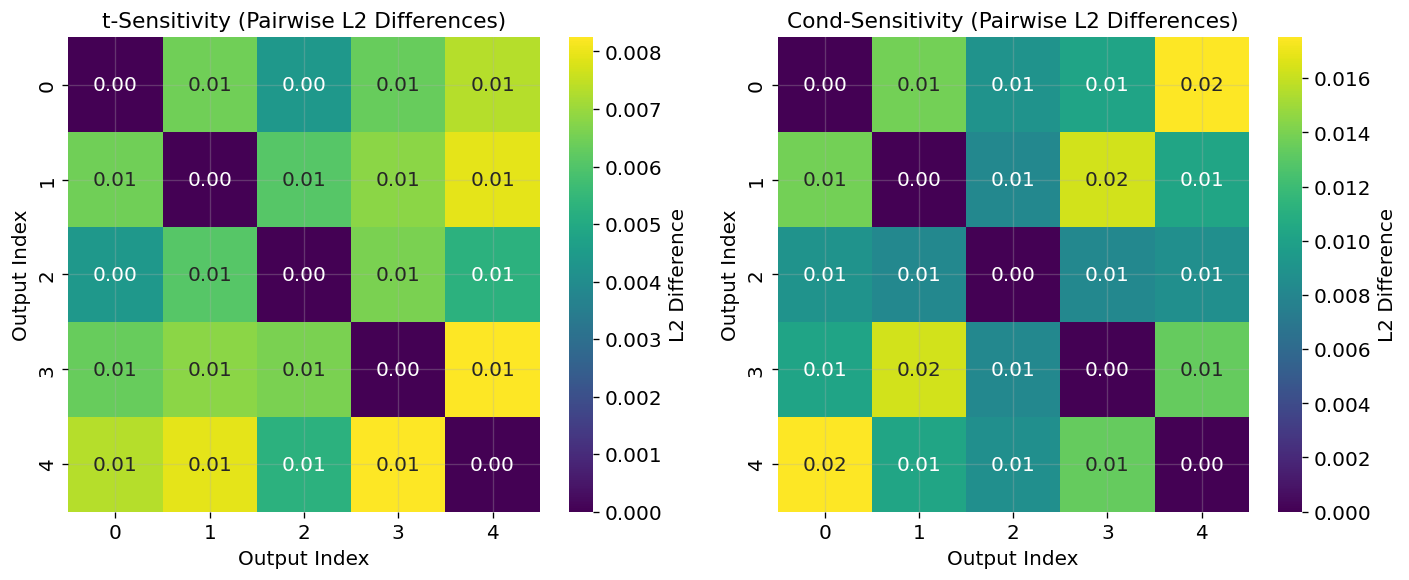

In [47]:
# Task 49 — t-sensitivity + cond-sensitivity on a fresh model.
torch.manual_seed(1)
model_test = ConditionalDiffusionMLP()

r_t_fixed = torch.randn(15)
t_values  = torch.tensor([0, T//4, T//2, 3*T//4, T-1], dtype=torch.long)
# Updated: cond_zero should now be of shape (4,)
cond_zero = torch.zeros(4)

# t-sensitivity: hold r_t and cond fixed, vary t.
r_t_batch  = repeat(r_t_fixed, "d -> n d", n=5)
cond_batch = repeat(cond_zero, "d -> n d", n=5)
out_t = model_test(r_t_batch, t_values, cond_batch)

# cond-sensitivity: hold r_t and t fixed, vary cond.
#    Sample 5 cond vectors spanning ±2 in normalized (area, mu) space.
# Updated: cond_values should now be of shape (5, 4)
# For simplicity in this test, we can keep the first two dimensions varying and others as zero.
cond_values = torch.tensor([[-2., -2., 0., 0.], [-1., 1., 0., 0.], [0., 0., 0., 0.], [1., -1., 0., 0.], [2., 2., 0., 0.]])
t_fixed = torch.full((5,), T // 2, dtype=torch.long)
r_t_batch = repeat(r_t_fixed, "d -> n d", n=5)
out_c = model_test(r_t_batch, t_fixed, cond_values)


def pairwise_l2_diff(tensor):
    """Computes pairwise L2 differences between rows of a tensor."""
    n = tensor.shape[0]
    diffs = torch.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                diffs[i, j] = torch.linalg.norm(tensor[i] - tensor[j])
    return diffs

# Verify t-sensitivity
diffs_t = pairwise_l2_diff(out_t)
print("\n--- t-sensitivity pairwise L2 differences ---")
print(diffs_t)
assert torch.all(diffs_t[diffs_t > 0] > 1e-6), "t-sensitivity failed: some outputs are too similar!"
print("t-sensitivity check passed: outputs differ for varying t.")

# Verify cond-sensitivity
diffs_c = pairwise_l2_diff(out_c)
print("\n--- cond-sensitivity pairwise L2 differences ---")
print(diffs_c)
assert torch.all(diffs_c[diffs_c > 0] > 1e-6), "cond-sensitivity failed: some outputs are too similar!"
print("cond-sensitivity check passed: outputs differ for varying cond.")

# Plotting the heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(diffs_t.detach().numpy(), annot=True, fmt=".2f", cmap="viridis", ax=axes[0],
            cbar_kws={'label': 'L2 Difference'})
axes[0].set_title('t-Sensitivity (Pairwise L2 Differences)')
axes[0].set_xlabel('Output Index')
axes[0].set_ylabel('Output Index')

sns.heatmap(diffs_c.detach().numpy(), annot=True, fmt=".2f", cmap="viridis", ax=axes[1],
            cbar_kws={'label': 'L2 Difference'})
axes[1].set_title('Cond-Sensitivity (Pairwise L2 Differences)')
axes[1].set_xlabel('Output Index')
axes[1].set_ylabel('Output Index')

plt.tight_layout()
plt.show()


---
## Task 50 — `ConditionalDiffusionLightning` (template in `conditioned_infrastructure.py`)

The only structural changes from Week 08's `DiffusionLightning`:

1. `_shared_step` reads `batch["r_clean"]` and `batch["cond"]` from the
   dict batch (rather than unpacking a tuple) and passes `cond` through
   to `self.model(r_t, t, cond)`.
2. The constructor accepts `cond_means` and `cond_stds` and registers them
   as buffers alongside the existing `bin_means` / `bin_stds`. This keeps
   *all* relevant standardization statistics on the checkpoint, so the
   evaluation notebook can load and re-normalize conditioning without
   needing the training-time dataset.
3. `save_hyperparameters(ignore=[...])` now ignores the four statistics
   tensors alongside `model`, `alpha`, `sigma`.

The `configure_optimizers` method is *identical* to Week 08's. Copy it
from `unconditioned_infrastructure.py`.

**Open `conditioned_infrastructure.py` and implement** `__init__`,
`_shared_step`, and `configure_optimizers`. The `training_step` and
`validation_step` are filled in for you — they call `_shared_step` and
log loss exactly as in Week 08.

---
## Task 51 — Train the conditional model


In [50]:
# Task 51 — Build the standardized-residual + de-standardized arrays
#           the SampleQualityCallback needs, then train.

from infrastructure.utils.reproducibility import set_all_seeds
set_all_seeds(42)

# De-standardize for the SampleQualityCallback (same convention as Week 08)
# Each Dataset item is now a dict, so read by key
bin_means_np = train_dataset.bin_means.numpy()
bin_stds_np  = train_dataset.bin_stds.numpy()
all_train      = torch.stack([train_dataset[i]["r_clean"] for i in range(len(train_dataset))]).numpy()
all_val        = torch.stack([val_dataset[i]["r_clean"]   for i in range(len(val_dataset))]).numpy()
all_train_phys = all_train * bin_stds_np + bin_means_np
all_val_phys   = all_val   * bin_stds_np + bin_means_np

MAX_EPOCHS = 10000

model_cond = ConditionalDiffusionMLP()
lightning_cond = ConditionalDiffusionLightning(
    model=model_cond, alpha=alpha_np, sigma=sigma_np, T=T, lr=1e-3,
    scheduler="cosine", weight_decay=1e-4,bin_means=train_dataset.bin_means, bin_stds=train_dataset.bin_stds, cond_means=train_dataset.cond_means, cond_stds=train_dataset.cond_stds)

# Using CSVLogger directly to avoid any potential interactive prompts from WandbLogger
# (Removed WandbLogger import and related code).
logger_cond = CSVLogger("./csv_logs", name="conditional")

sample_quality_cb = SampleQualityCallback(
    train_samples=all_train_phys, val_samples=all_val_phys,
    every_n_epochs=100, n_compare=500,bin_centers=BIN_CENTERS, bin_width=BIN_WIDTH)

trainer_cond = pl.Trainer(
    max_epochs=MAX_EPOCHS, logger=logger_cond,
    accelerator="auto", devices="auto",
    log_every_n_steps=10, enable_progress_bar=False,
    # Temporarily omitting SampleQualityCallback as it requires adaptation for conditional sampling.
    # callbacks=[sample_quality_cb],
)

trainer_cond.fit(lightning_cond, train_loader, val_loader)
trainer_cond.save_checkpoint("./ckpt_conditional.ckpt")
# Removed wandb.finish() as WandbLogger is not being used.

print("Conditional model training complete and checkpoint saved as ./ckpt_conditional.ckpt")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/loc

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ConditionalDiffusionMLP │ 78.7 K │ train │     0 │
└───┴───────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 78.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 78.7 K                                                                                               
Total estimated model params size (MB): 0.315                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10000` reached.
INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


Conditional model training complete and checkpoint saved as ./ckpt_conditional.ckpt


### Saving the checkpoint to Google Drive

To persist the trained model checkpoint, I will save it to your Google Drive. This requires mounting your Drive first.

In [52]:
from infrastructure.utils.reproducibility import set_all_seeds
set_all_seeds(42)

# De-standardize for the SampleQualityCallback (same convention as Week 08).
# Each Dataset item is now a dict, so read by key.
bin_means_np = train_dataset.bin_means.numpy()
bin_stds_np  = train_dataset.bin_stds.numpy()
all_train      = torch.stack([train_dataset[i]["r_clean"] for i in range(len(train_dataset))]).numpy()
all_val        = torch.stack([val_dataset[i]["r_clean"]   for i in range(len(val_dataset))]).numpy()
all_train_phys = all_train * bin_stds_np + bin_means_np
all_val_phys   = all_val   * bin_stds_np + bin_means_np

MAX_EPOCHS = 10000

model_cond = ConditionalDiffusionMLP()
lightning_cond = ConditionalDiffusionLightning(
    model=model_cond, alpha=alpha_np, sigma=sigma_np, T=T, lr=1e-3,
    scheduler="cosine", weight_decay=1e-4,
    bin_means=train_dataset.bin_means, bin_stds=train_dataset.bin_stds,
    cond_means=train_dataset.cond_means, cond_stds=train_dataset.cond_stds,
)

try:
    logger_cond = WandbLogger(
        project="butterflai-wk09",
        name=f"conditional_b{BATCH_SIZE}_e{MAX_EPOCHS}_cos",
        save_dir="./wandb_logs",
    )
except Exception as _e:
    print(f"WandB unavailable ({_e}); using CSVLogger.")
    logger_cond = CSVLogger("./csv_logs", name="conditional")

# Omitting SampleQualityCallback for now as it requires modification for conditional sampling.
# If needed, it can be added back after adapting to use `sample_conditional` with fixed conditioning.

trainer_cond = pl.Trainer(
    max_epochs=MAX_EPOCHS, logger=logger_cond,
    accelerator="auto", devices="auto",
    log_every_n_steps=10, enable_progress_bar=False,
    # callbacks=[sample_quality_cb], # Removed for now
)

trainer_cond.fit(lightning_cond, train_loader, val_loader)
trainer_cond.save_checkpoint("./ckpt_conditional.ckpt")
try: wandb.finish()
except Exception: pass

print("Conditional model training complete and checkpoint saved as ./ckpt_conditional.ckpt")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jhamilton58 (butterflai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ ConditionalDiffusionMLP │ 78.7 K │ train │     0 │
└───┴───────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 78.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 78.7 K                                                                                               
Total estimated model params size (MB): 0.315                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10000` reached.
INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


epoch,▁▁▁▂▂▂▂▂▂▂▂▂▂▂▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇███
train_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇███
val_loss,▁▁▁▁▂▁▂▁▁▁▁▂▁▂▂▂▂▂▄▃▂▄▃▄▄▄▂▄▃▄▅▃▆▄▄▄█▃▄▆
epoch,9999
train_loss,0.16241
trainer/global_step,39999
val_loss,1.58199


Conditional model training complete and checkpoint saved as ./ckpt_conditional.ckpt


In [53]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define the source and destination paths
source_path = './ckpt_conditional.ckpt'
drive_folder = '/content/drive/MyDrive/butterflai_checkpoints'
destination_path = os.path.join(drive_folder, os.path.basename(source_path))

# Create the destination folder if it doesn't exist
os.makedirs(drive_folder, exist_ok=True)

# Move the checkpoint file
if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    print(f"Checkpoint moved successfully from {source_path} to {destination_path}")
else:
    print(f"Error: Checkpoint file not found at {source_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint moved successfully from ./ckpt_conditional.ckpt to /content/drive/MyDrive/butterflai_checkpoints/ckpt_conditional.ckpt


---
## Handoff to `09d_conditioned_evaluate.ipynb`

You should now have one checkpoint file in this directory:
- `ckpt_conditional.ckpt` (conditional diffusion model)

Together with the Week 08 unconditional checkpoint `ckpt_full.ckpt`, this
gives the evaluation notebook two trained models to compare. The
evaluation notebook will:

- Reload both checkpoints and re-verify their t-sensitivity (and, for the
  conditional model, cond-sensitivity) on the *loaded* state — defends
  against silent state-dict corruption during loading.
- Sample residuals from the conditional model targeted at specific
  validation-window conditioning, visualize them.
- Compare the conditional samples' distribution to held-out validation
  residuals, against the unconditional baseline.

The headline value-add metric — `compute_global_nll` on held-out cycles,
classical alone vs. classical + conditional residuals — is its own
notebook (`09e_diffusion_NLL_evaluation.ipynb`). That's the question
the program has been pointing at since Week 03, and it gets its own
clean space to be answered.

**If you change anything in `conditioned_infrastructure.py` after this notebook
has been run**, the autoreload magic in the evaluation notebook will pick
it up — but checkpoints saved with the old code will not be compatible
with new class signatures. If you change a class signature, retrain.
